# MoE Model Evaluation

## Part 0: Setup

In [4]:
# Install Dependencies
!pip install datasets transformers torch

Define some macros

In [5]:
import torch

context_length = 512
batch_size = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Part 1: Load Test Data

In [6]:
import os
import time
import logging
from tqdm import tqdm
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

# === Setup ===
logging.basicConfig(level=logging.WARNING)
os.makedirs("./data", exist_ok=True)

# === Constants ===
context_length = 1024
batch_size = 4
num_test_examples = 1000
tokenizer = AutoTokenizer.from_pretrained("stevensu123/gpt2-moe-topk")

# === Tokenization Function ===
def tokenize_function(example):
    return tokenizer(example["text"], return_attention_mask=False)

# === Group Texts into Chunks of Context Length ===
def group_texts(examples):
    concatenated = sum(examples["input_ids"], [])
    total_length = (len(concatenated) // context_length) * context_length
    input_ids = [concatenated[i:i + context_length] for i in range(0, total_length, context_length)]
    return {"input_ids": input_ids, "labels": input_ids}

# === Collect and Preprocess Test Data ===
def get_tokenized_test_data(num_examples=1000, max_retries=5, delay=2):
    stream = load_dataset("cerebras/SlimPajama-627B", split="test", streaming=True)
    iterator = iter(stream)
    examples = []
    pbar = tqdm(total=num_examples, desc=f"Collecting test examples")

    while len(examples) < num_examples:
        try:
            example = next(iterator)
            examples.append(example)
            pbar.update(1)
        except StopIteration:
            logging.warning(f"Reached end of stream before collecting {num_examples} examples.")
            break
        except Exception as e:
            retries = 0
            logging.warning(f"Error while collecting test example {len(examples)}: {e}")
            while retries < max_retries:
                try:
                    time.sleep(delay)
                    example = next(iterator)
                    examples.append(example)
                    pbar.update(1)
                    break
                except Exception as e_retry:
                    retries += 1
                    logging.warning(f"Retry {retries}/{max_retries} failed: {e_retry}")
            else:
                logging.warning(f"Skipping test example after {max_retries} retries.")
    pbar.close()

    raw_dataset = Dataset.from_dict({'text': [ex['text'] for ex in examples]})
    tokenized = raw_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
    grouped = tokenized.map(group_texts, batched=True)
    return grouped

# === Final Test Dataloader ===
test_dataset = get_tokenized_test_data(num_examples=num_test_examples)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

Resolving data files:   0%|          | 0/59166 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31428 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31411 [00:00<?, ?it/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (4336 > 1024). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

## Part 2: Loading Baseline

Load GPT2

In [7]:
# prompt: load GPT2-large

import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load pre-trained GPT-2 model and tokenizer
baseline_model = GPT2LMHeadModel.from_pretrained('stevensu123/baseline')
baseline_tokenizer = GPT2Tokenizer.from_pretrained('stevensu123/baseline')

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model.to(device)
baseline_model.eval()


config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.10G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1280)
    (wpe): Embedding(1024, 1280)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-35): 36 x GPT2Block(
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3840, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=1280)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=5120, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=5120)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1280, out_features=50257, bias=False)
)

Do a test inference run

In [8]:
# Example usage:
input_text = "Once upon a time"
input_ids = baseline_tokenizer.encode(input_text, return_tensors="pt").to(device)

# Generate text
output_ids = baseline_model.generate(
    input_ids,
    max_length=50,
    num_return_sequences=1,
    no_repeat_ngram_size=2,
    early_stopping=True,
)

# Decode and print the output
output_text = baseline_tokenizer.decode(output_ids[0], skip_special_tokens=True)
output_text


/home/ec2-user/dynamic_moe/.venv/lib64/python3.9/site-packages/transformers/generation/configuration_utils.py:679: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


'Once upon a time, there was a man named John. He was an old man, and he had a wife and a son. One day, he was walking down the street, when he saw a woman walking by. She was beautiful, but'

## Part 3: Loading GPT2-MoE Top-k

Load the Model

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Conv1D(nn.Module):
    def __init__(self, nf, nx):
        super().__init__()
        self.nf = nf
        w = torch.empty(nx, nf)
        nn.init.normal_(w, std=0.02)
        self.weight = nn.Parameter(w)
        self.bias = nn.Parameter(torch.zeros(nf))

    def forward(self, x):
        size_out = x.size()[:-1] + (self.nf,)
        x_view = x.view(-1, x.size(-1))
        result = x_view @ self.weight + self.bias
        return result.view(*size_out)

In [10]:
class ExpertLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.c_fc = Conv1D(hidden_dim, input_dim)
        self.c_proj = Conv1D(input_dim, hidden_dim)
        self.act = nn.GELU(approximate="tanh")

    def forward(self, x):
        hidden = self.c_fc(x)
        hidden = self.act(hidden)
        output = self.c_proj(hidden)
        return output

In [11]:
class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_experts=4, top_k=2, balance_loss_weight=0.01):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_experts = num_experts
        self.top_k = top_k
        self.balance_loss_weight = balance_loss_weight

        self.experts = nn.ModuleList([
            ExpertLayer(input_dim, hidden_dim)
            for _ in range(num_experts)
        ])
        self.router = nn.Linear(input_dim, num_experts)
        self.register_buffer("usage_counter", torch.zeros(num_experts))

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        device = x.device

        router_logits = self.router(x)  # [B, T, E]
        routing_weights = F.softmax(router_logits, dim=-1)  # [B, T, E]

        topk_weights, topk_indices = torch.topk(routing_weights, self.top_k, dim=-1)  # [B, T, k]
        topk_weights /= topk_weights.sum(dim=-1, keepdim=True)  # Normalize

        x_flat = x.reshape(-1, d_model)  # [B*T, D]
        output_flat = torch.zeros_like(x_flat)
        expert_counts = torch.zeros(self.num_experts, device=device)

        topk_indices_flat = topk_indices.reshape(-1, self.top_k)
        topk_weights_flat = topk_weights.reshape(-1, self.top_k)

        for expert_id in range(self.num_experts):
            mask = (topk_indices_flat == expert_id)
            if not mask.any():
                continue

            token_indices, slot_indices = mask.nonzero(as_tuple=True)
            weights = topk_weights_flat[token_indices, slot_indices]
            x_selected = x_flat[token_indices]

            y_selected = self.experts[expert_id](x_selected)
            output_flat[token_indices] += weights.unsqueeze(1) * y_selected
            expert_counts[expert_id] = token_indices.numel()
            self.usage_counter[expert_id] += token_indices.numel()

        output = output_flat.view(batch_size, seq_len, d_model)

        num_tokens = batch_size * seq_len
        expert_fractions = expert_counts / (num_tokens * self.top_k)
        balance_loss = self.num_experts * torch.sum(expert_fractions ** 2)
        router_z_loss = torch.mean(torch.sum(router_logits ** 2, dim=-1))
        aux_loss = self.balance_loss_weight * (balance_loss + 0.001 * router_z_loss)
        self.aux_loss = aux_loss

        return output, aux_loss

In [12]:
class GPT2MoEBlock(nn.Module):
    def __init__(self, original_block, num_experts=4, top_k=2, balance_loss_weight=0.01):
        super().__init__()

        # Retain the same attention block and layer norm before the attention block and the MLP layer
        self.attn = original_block.attn
        self.ln_1 = original_block.ln_1
        self.ln_2 = original_block.ln_2
        hidden_size = original_block.ln_1.weight.size(0)
        intermediate_size = original_block.mlp.c_fc.weight.shape[1]

        # we will use the MoE block that we just defined to replace the MLPs in the attention block
        self.mlp = MixtureOfExperts(
            input_dim=hidden_size,
            hidden_dim=intermediate_size,
            num_experts=num_experts,
            top_k=top_k,
            balance_loss_weight=balance_loss_weight
        )

        # here, we loop through each expert block in the Mixture of expert layer and initialize their weights & biases
        for expert in self.mlp.experts:
            with torch.no_grad():

                # copy the weights of the original MLP block's up projection layer to each expert and normalize by division of the number of experts
                expert.c_fc.weight.data = original_block.mlp.c_fc.weight.clone().to(expert.c_fc.weight.device) / num_experts

                # copy the bias of the original MLP block's up projection layer to each expert and normalize by division of the number of experts
                expert.c_fc.bias.data = original_block.mlp.c_fc.bias.clone().to(expert.c_fc.bias.device) / num_experts

                # copy the weights of the original MLP block's down projection layer to each expert and normalize by division of the number of experts
                expert.c_proj.weight.data = original_block.mlp.c_proj.weight.clone().to(expert.c_proj.weight.device) / num_experts

                # copy the bias of the original MLP block's down projection layer to each expert and normalize by division of the number of experts
                expert.c_proj.bias.data = original_block.mlp.c_proj.bias.clone().to(expert.c_proj.bias.device) / num_experts

        with torch.no_grad():
            # initialize the router network's weights via random noise through a normal distribution
            nn.init.normal_(self.mlp.router.weight, mean=0.0, std=0.01)

        device = next(original_block.parameters()).device
        self = self.to(device)

    def forward(
        self,
        hidden_states,
        layer_past=None,
        attention_mask=None,
        head_mask=None,
        encoder_hidden_states=None,
        encoder_attention_mask=None,
        use_cache=False,
        output_attentions=False,
        **kwargs
    ):

        # Residual connection. this is the input
        residual = hidden_states

        # Layer norm before passing input into attention
        hidden_states = self.ln_1(hidden_states)

        # arguments for the attention block
        attn_args = {
            "hidden_states": hidden_states,
            "layer_past": layer_past,
            "attention_mask": attention_mask,
            "head_mask": head_mask,
            "use_cache": use_cache,
            "output_attentions": output_attentions,
        }

        # passing in redundant arguments
        for key in kwargs:
            if key in ["position_ids", "position_embeddings"]:
                attn_args[key] = kwargs[key]

        # outputs from the attention block
        attn_outputs = self.attn(**attn_args)
        attn_output = attn_outputs[0]
        outputs = attn_outputs[1:]

        # Residual connection mechanism, adding the residual back to the input
        hidden_states = attn_output + residual

        # Second residual connection
        residual = hidden_states

        # Layer norm post attention block
        hidden_states = self.ln_2(hidden_states)

        # Passing into the mixture of experts layer
        hidden_states_moe, aux_loss = self.mlp(hidden_states)
        hidden_states = hidden_states_moe + residual

        # second residual connection
        if use_cache:
            outputs = (hidden_states,) + outputs
        else:
            outputs = (hidden_states,) + outputs[1:]
        return outputs

In [14]:
from transformers import GPT2LMHeadModel

class GPT2MoEModel(GPT2LMHeadModel):
    def __init__(self, config, num_experts=4, top_k=2):
        super().__init__(config)
        self.num_experts = num_experts
        self.top_k = top_k

    def inject_moe(self):
        total_layers = len(self.transformer.h)
        for idx in range(0, total_layers, 4):
            self.transformer.h[idx] = GPT2MoEBlock(
                self.transformer.h[idx], self.num_experts, self.top_k
            )

top_k_model = GPT2MoEModel.from_pretrained("stevensu123/gpt2-moe-topk")
top_k_tokenizer = AutoTokenizer.from_pretrained("stevensu123/gpt2-moe-topk")
top_k_model.inject_moe()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
top_k_model.to(device)
top_k_model.eval()

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.51G [00:00<?, ?B/s]

Some weights of the model checkpoint at stevensu123/gpt2-moe-topk were not used when initializing GPT2MoEModel: ['transformer.h.0.mlp.experts.0.c_fc.bias', 'transformer.h.0.mlp.experts.0.c_fc.weight', 'transformer.h.0.mlp.experts.0.c_proj.bias', 'transformer.h.0.mlp.experts.0.c_proj.weight', 'transformer.h.0.mlp.experts.1.c_fc.bias', 'transformer.h.0.mlp.experts.1.c_fc.weight', 'transformer.h.0.mlp.experts.1.c_proj.bias', 'transformer.h.0.mlp.experts.1.c_proj.weight', 'transformer.h.0.mlp.experts.2.c_fc.bias', 'transformer.h.0.mlp.experts.2.c_fc.weight', 'transformer.h.0.mlp.experts.2.c_proj.bias', 'transformer.h.0.mlp.experts.2.c_proj.weight', 'transformer.h.0.mlp.experts.3.c_fc.bias', 'transformer.h.0.mlp.experts.3.c_fc.weight', 'transformer.h.0.mlp.experts.3.c_proj.bias', 'transformer.h.0.mlp.experts.3.c_proj.weight', 'transformer.h.0.mlp.router.bias', 'transformer.h.0.mlp.router.weight', 'transformer.h.12.mlp.experts.0.c_fc.bias', 'transformer.h.12.mlp.experts.0.c_fc.weight', 'tran

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

GPT2MoEModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1280)
    (wpe): Embedding(1024, 1280)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0): GPT2MoEBlock(
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3840, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=1280)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (mlp): MixtureOfExperts(
          (experts): ModuleList(
            (0-3): 4 x ExpertLayer(
              (c_fc): Conv1D()
              (c_proj): Conv1D()
              (act): GELU(approximate='tanh')
            )
          )
          (router): Linear(in_features=1280, out_features=4, bias=True)
        )
      )
      (1-3): 3 x GPT2Block(
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_aff

Do a test inference run

In [15]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Set pad_token_id to eos_token_id if not already set
top_k_model.config.pad_token_id = top_k_model.config.eos_token_id

# Prepare input
input_text = "Once upon a time"
input_ids = top_k_tokenizer.encode(input_text, return_tensors='pt').to(device)

# Generate text
output_ids = top_k_model.generate(
    input_ids,
    max_length=50,
    num_return_sequences=1,
    no_repeat_ngram_size=2,
    early_stopping=True
)

# Decode and print the output
output_text = top_k_tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(output_text)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Once upon a time, the world of the internet is a very of its day. There are so many things to do with the web that it's hard to keep track of it all of us time.
But that's not to say this,


## Part 4: Loading GPT2-MoE Top-p

Load the model

In [18]:
class Conv1D(nn.Module):
    def __init__(self, nf, nx):
        super().__init__()
        self.nf = nf
        w = torch.empty(nx, nf)
        nn.init.normal_(w, std=0.02)
        self.weight = nn.Parameter(w)
        self.bias = nn.Parameter(torch.zeros(nf))

    def forward(self, x):
        size_out = x.size()[:-1] + (self.nf,)
        x_view = x.view(-1, x.size(-1))
        result = x_view @ self.weight + self.bias
        return result.view(*size_out)

In [19]:
class ExpertLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.c_fc = Conv1D(hidden_dim, input_dim)
        self.c_proj = Conv1D(input_dim, hidden_dim)
        self.act = nn.GELU(approximate="tanh")

    def forward(self, x):
        hidden = self.c_fc(x)
        hidden = self.act(hidden)
        output = self.c_proj(hidden)
        return output

In [20]:
class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_experts=4, top_p=0.8, balance_loss_weight=0.01):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_experts = num_experts
        self.top_p = top_p
        self.balance_loss_weight = balance_loss_weight

        self.experts = nn.ModuleList([
            ExpertLayer(input_dim, hidden_dim)
            for _ in range(num_experts)
        ])
        self.router = nn.Linear(input_dim, num_experts)
        self.register_buffer("usage_counter", torch.zeros(num_experts))

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        device = x.device

        router_logits = self.router(x)  # [B, T, E]
        routing_probs = F.softmax(router_logits, dim=-1)  # [B, T, E]

        sorted_probs, sorted_indices = torch.sort(routing_probs, dim=-1, descending=True)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

        top_p_mask = cumulative_probs <= self.top_p
        top_p_mask[..., 0] = 1  # Ensure at least one expert is selected

        expert_mask = torch.zeros_like(routing_probs, dtype=torch.bool)
        expert_mask.scatter_(-1, sorted_indices, top_p_mask)

        selected_routing_probs = routing_probs * expert_mask
        normalized_probs = selected_routing_probs / (selected_routing_probs.sum(dim=-1, keepdim=True) + 1e-9)

        x_flat = x.reshape(-1, d_model)
        output_flat = torch.zeros_like(x_flat)
        expert_counts = torch.zeros(self.num_experts, device=device)

        for expert_id in range(self.num_experts):
            mask = expert_mask[..., expert_id].reshape(-1)
            if not mask.any():
                continue

            token_indices = mask.nonzero(as_tuple=False).squeeze(1)
            x_selected = x_flat[token_indices]
            weights = normalized_probs[..., expert_id].reshape(-1)[token_indices]

            y_selected = self.experts[expert_id](x_selected)
            output_flat[token_indices] += weights.unsqueeze(1) * y_selected
            expert_counts[expert_id] = token_indices.numel()
            self.usage_counter[expert_id] += token_indices.numel()

        output = output_flat.view(batch_size, seq_len, d_model)

        num_tokens = batch_size * seq_len
        expert_fractions = expert_counts / num_tokens
        balance_loss = self.num_experts * torch.sum(expert_fractions ** 2)
        router_z_loss = torch.mean(torch.sum(router_logits ** 2, dim=-1))
        aux_loss = self.balance_loss_weight * (balance_loss + 0.001 * router_z_loss)
        self.aux_loss = aux_loss

        return output, aux_loss

In [21]:
class GPT2MoEBlock(nn.Module):
    def __init__(self, original_block, num_experts=4, top_p=0.8, balance_loss_weight=0.01):
        super().__init__()

        # Retain the same attention block and layer norm before the attention block and the MLP layer
        self.attn = original_block.attn
        self.ln_1 = original_block.ln_1
        self.ln_2 = original_block.ln_2
        hidden_size = original_block.ln_1.weight.size(0)
        intermediate_size = original_block.mlp.c_fc.weight.shape[1]

        # we will use the MoE block that we just defined to replace the MLPs in the attention block
        self.mlp = MixtureOfExperts(
            input_dim=hidden_size,
            hidden_dim=intermediate_size,
            num_experts=num_experts,
            top_p=top_p,
            balance_loss_weight=balance_loss_weight
        )

        # here, we loop through each expert block in the Mixture of expert layer and initialize their weights & biases
        for expert in self.mlp.experts:
            with torch.no_grad():

                # copy the weights of the original MLP block's up projection layer to each expert and normalize by division of the number of experts
                expert.c_fc.weight.data = original_block.mlp.c_fc.weight.clone().to(expert.c_fc.weight.device) / num_experts

                # copy the bias of the original MLP block's up projection layer to each expert and normalize by division of the number of experts
                expert.c_fc.bias.data = original_block.mlp.c_fc.bias.clone().to(expert.c_fc.bias.device) / num_experts

                # copy the weights of the original MLP block's down projection layer to each expert and normalize by division of the number of experts
                expert.c_proj.weight.data = original_block.mlp.c_proj.weight.clone().to(expert.c_proj.weight.device) / num_experts

                # copy the bias of the original MLP block's down projection layer to each expert and normalize by division of the number of experts
                expert.c_proj.bias.data = original_block.mlp.c_proj.bias.clone().to(expert.c_proj.bias.device) / num_experts

        with torch.no_grad():
            # initialize the router network's weights via random noise through a normal distribution
            nn.init.normal_(self.mlp.router.weight, mean=0.0, std=0.01)

        device = next(original_block.parameters()).device
        self = self.to(device)

    def forward(
        self,
        hidden_states,
        layer_past=None,
        attention_mask=None,
        head_mask=None,
        encoder_hidden_states=None,
        encoder_attention_mask=None,
        use_cache=False,
        output_attentions=False,
        **kwargs
    ):

        # Residual connection. this is the input
        residual = hidden_states

        # Layer norm before passing input into attention
        hidden_states = self.ln_1(hidden_states)

        # arguments for the attention block
        attn_args = {
            "hidden_states": hidden_states,
            "layer_past": layer_past,
            "attention_mask": attention_mask,
            "head_mask": head_mask,
            "use_cache": use_cache,
            "output_attentions": output_attentions,
        }

        # passing in redundant arguments
        for key in kwargs:
            if key in ["position_ids", "position_embeddings"]:
                attn_args[key] = kwargs[key]

        # outputs from the attention block
        attn_outputs = self.attn(**attn_args)
        attn_output = attn_outputs[0]
        outputs = attn_outputs[1:]

        # Residual connection mechanism, adding the residual back to the input
        hidden_states = attn_output + residual

        # Second residual connection
        residual = hidden_states

        # Layer norm post attention block
        hidden_states = self.ln_2(hidden_states)

        # Passing into the mixture of experts layer
        hidden_states_moe, aux_loss = self.mlp(hidden_states)
        hidden_states = hidden_states_moe + residual

        # second residual connection
        if use_cache:
            outputs = (hidden_states,) + outputs
        else:
            outputs = (hidden_states,) + outputs[1:]
        return outputs

In [22]:
from transformers import GPT2LMHeadModel

class GPT2MoEModel(GPT2LMHeadModel):
    def __init__(self, config, num_experts=4, top_p=0.8):
        super().__init__(config)
        self.num_experts = num_experts
        self.top_p = top_p

    def inject_moe(self):
        total_layers = len(self.transformer.h)
        for idx in range(0, total_layers, 4):
            self.transformer.h[idx] = GPT2MoEBlock(
                self.transformer.h[idx], self.num_experts, self.top_p
            )

top_p_model = GPT2MoEModel.from_pretrained("stevensu123/gpt2-moe-topp")
top_p_tokenizer = AutoTokenizer.from_pretrained("stevensu123/gpt2-moe-topp")
top_p_model.inject_moe()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
top_p_model.to(device)
top_p_model.eval()

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.51G [00:00<?, ?B/s]

Some weights of the model checkpoint at stevensu123/gpt2-moe-topp were not used when initializing GPT2MoEModel: ['transformer.h.0.mlp.experts.0.c_fc.bias', 'transformer.h.0.mlp.experts.0.c_fc.weight', 'transformer.h.0.mlp.experts.0.c_proj.bias', 'transformer.h.0.mlp.experts.0.c_proj.weight', 'transformer.h.0.mlp.experts.1.c_fc.bias', 'transformer.h.0.mlp.experts.1.c_fc.weight', 'transformer.h.0.mlp.experts.1.c_proj.bias', 'transformer.h.0.mlp.experts.1.c_proj.weight', 'transformer.h.0.mlp.experts.2.c_fc.bias', 'transformer.h.0.mlp.experts.2.c_fc.weight', 'transformer.h.0.mlp.experts.2.c_proj.bias', 'transformer.h.0.mlp.experts.2.c_proj.weight', 'transformer.h.0.mlp.experts.3.c_fc.bias', 'transformer.h.0.mlp.experts.3.c_fc.weight', 'transformer.h.0.mlp.experts.3.c_proj.bias', 'transformer.h.0.mlp.experts.3.c_proj.weight', 'transformer.h.0.mlp.router.bias', 'transformer.h.0.mlp.router.weight', 'transformer.h.12.mlp.experts.0.c_fc.bias', 'transformer.h.12.mlp.experts.0.c_fc.weight', 'tran

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

GPT2MoEModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1280)
    (wpe): Embedding(1024, 1280)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0): GPT2MoEBlock(
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3840, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=1280)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (mlp): MixtureOfExperts(
          (experts): ModuleList(
            (0-3): 4 x ExpertLayer(
              (c_fc): Conv1D()
              (c_proj): Conv1D()
              (act): GELU(approximate='tanh')
            )
          )
          (router): Linear(in_features=1280, out_features=4, bias=True)
        )
      )
      (1-3): 3 x GPT2Block(
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_aff

Do a test inference

In [23]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer


# Set pad_token_id to eos_token_id if not already set
top_p_model.config.pad_token_id = top_p_model.config.eos_token_id

# Prepare input
input_text = "Once upon a time"
input_ids = top_p_tokenizer.encode(input_text, return_tensors='pt').to(device)

# Generate text
output_ids = top_p_model.generate(
    input_ids,
    max_length=50,
    num_return_sequences=1,
    no_repeat_ngram_size=2,
    early_stopping=True
)

# Decode and print the output
output_text = top_p_tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(output_text)


/home/ec2-user/dynamic_moe/.venv/lib64/python3.9/site-packages/transformers/generation/configuration_utils.py:679: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Once upon a time, I was in a bar, and I had a few time time was talking to a girl I knew, she said, that I said I thought I would. I told I should.
I said that was the last thing


## Part 5: Evaluations

In [24]:
import torch
import time
import psutil
import os
from tqdm import tqdm

def evaluate_model(model, test_dataloader, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    inference_times = []
    peak_memories = []
    average_memories = []

    process = psutil.Process(os.getpid())

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc="Evaluating"):
            input_ids = torch.stack(batch["input_ids"]).to(device)
            labels = torch.stack(batch["labels"]).to(device)

            # Memory before inference
            if device == "cuda":
                torch.cuda.reset_peak_memory_stats()
            mem_before = process.memory_info().rss

            start_time = time.perf_counter()
            outputs = model(input_ids=input_ids, labels=labels)
            end_time = time.perf_counter()

            loss = outputs.loss
            batch_tokens = input_ids.numel()
            total_loss += loss.item() * batch_tokens
            total_tokens += batch_tokens

            mem_after = process.memory_info().rss
            peak_mem = (
                torch.cuda.max_memory_allocated(device=device)
                if device == "cuda"
                else mem_after
            )

            elapsed = end_time - start_time

            # Log stats
            inference_times.append(elapsed)
            average_memories.append((mem_after + mem_before) / 2)
            peak_memories.append(peak_mem)

    average_loss = total_loss / total_tokens
    perplexity = torch.exp(torch.tensor(average_loss))

    print(f"\n🧪 Evaluation Results:")
    print(f"  - Average Loss: {average_loss:.4f}")
    print(f"  - Perplexity: {perplexity:.2f}")
    print(f"  - Total Inference Time: {sum(inference_times):.2f}s")
    print(f"  - Average Time per Batch: {sum(inference_times)/len(inference_times):.4f}s")
    print(f"  - Average Time per Token: {sum(inference_times)/total_tokens * 1000:.4f} ms")
    print(f"  - Average Peak Memory per Batch: {sum(peak_memories) / len(peak_memories) / 1024**2:.2f} MB")
    print(f"  - Average Memory Used per Batch: {sum(average_memories) / len(average_memories) / 1024**2:.2f} MB")

    return {
        "loss": average_loss,
        "perplexity": perplexity.item(),
        "inference_times": inference_times,
        "peak_memories": peak_memories,
        "average_memories": average_memories,
    }


In [16]:
import torch
from collections import defaultdict
import numpy as np
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

def evaluate_expert_usage(model, test_dataloader, device):
    model.eval()
    total_tokens = 0

    metrics = {
        'expert_usage_per_token': [],
        'input_difficulties': [],
        'expert_distribution': defaultdict(int)
    }

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc="Evaluating Expert Usage"):
            input_ids = torch.stack(batch["input_ids"]).to(device)
            batch_tokens = input_ids.numel()
            total_tokens += batch_tokens

            outputs = model(input_ids=input_ids)

            total_expert_use = 0

            # Count expert activations
            for block in model.transformer.h:
                if isinstance(block, GPT2MoEBlock):
                    moe_layer = block.mlp
                    expert_weights = moe_layer.usage_counter  # [num_experts]
                    total_expert_use += expert_weights.sum().item()

                    for expert_id in range(len(expert_weights)):
                        metrics['expert_distribution'][expert_id] += expert_weights[expert_id].item()

                    moe_layer.usage_counter.zero_()  # Reset after each batch

            # Record average expert usage per token
            metrics['expert_usage_per_token'].append(total_expert_use / batch_tokens)

            # Input difficulty: entropy of softmax
            logits = outputs.logits
            probs = F.softmax(logits, dim=-1)
            entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=-1)
            metrics['input_difficulties'].append(entropy.mean().item())

    # Final Metrics
    metrics['avg_experts_per_token'] = np.mean(metrics['expert_usage_per_token'])
    metrics['std_experts_per_token'] = np.std(metrics['expert_usage_per_token'])

    if metrics['input_difficulties'] and metrics['expert_usage_per_token']:
        metrics['difficulty_expert_correlation'] = np.corrcoef(
            metrics['input_difficulties'],
            metrics['expert_usage_per_token']
        )[0, 1]

    total_usage = sum(metrics['expert_distribution'].values())
    if total_usage > 0:
        for expert_id in metrics['expert_distribution']:
            metrics['expert_distribution'][expert_id] /= total_usage

    # Print metrics
    print("\n📊 Expert Usage Metrics:")
    print(f"  - Average experts per token: {metrics['avg_experts_per_token']:.4f} ± {metrics['std_experts_per_token']:.4f}")
    if 'difficulty_expert_correlation' in metrics:
        print(f"  - Correlation (difficulty vs expert usage): {metrics['difficulty_expert_correlation']:.4f}")
    print("\nExpert Distribution:")
    for expert_id, usage in metrics['expert_distribution'].items():
        print(f"  - Expert {expert_id}: {usage:.2%}")

    # Plot expert distribution
    plt.figure(figsize=(10, 6))
    plt.bar(metrics['expert_distribution'].keys(), metrics['expert_distribution'].values())
    plt.title("Expert Usage Distribution")
    plt.xlabel("Expert ID")
    plt.ylabel("Usage Percentage")
    plt.show()

    # Plot difficulty vs usage
    plt.figure(figsize=(10, 6))
    plt.scatter(metrics['input_difficulties'], metrics['expert_usage_per_token'], alpha=0.5)
    plt.title("Input Difficulty vs Expert Usage")
    plt.xlabel("Input Difficulty (Entropy)")
    plt.ylabel("Experts per Token")
    plt.show()

    return metrics


In [25]:
baseline_results = evaluate_model(baseline_model, test_dataloader, device)

Evaluating: 100%|██████████| 238/238 [01:46<00:00,  2.24it/s]


🧪 Evaluation Results:
  - Average Loss: 9.9665
  - Perplexity: 21299.77
  - Total Inference Time: 7.12s
  - Average Time per Batch: 0.0299s
  - Average Time per Token: 0.0073 ms
  - Average Peak Memory per Batch: 7495.97 MB
  - Average Memory Used per Batch: 7495.96 MB


In [26]:
top_k_results=evaluate_model(top_k_model, test_dataloader, device)

Evaluating: 100%|██████████| 238/238 [02:03<00:00,  1.92it/s]


🧪 Evaluation Results:
  - Average Loss: 9.6031
  - Perplexity: 14810.99
  - Total Inference Time: 103.52s
  - Average Time per Batch: 0.4349s
  - Average Time per Token: 0.1063 ms
  - Average Peak Memory per Batch: 7496.60 MB
  - Average Memory Used per Batch: 7496.60 MB


Evaluating Expert Usage: 100%|██████████| 238/238 [02:16<00:00,  1.74it/s]


📊 Expert Usage Metrics:
  - Average experts per token: 18.0009 ± 0.0139
  - Correlation (difficulty vs expert usage): 0.0274

Expert Distribution:
  - Expert 0: 26.34%
  - Expert 1: 24.71%
  - Expert 2: 18.40%
  - Expert 3: 30.55%


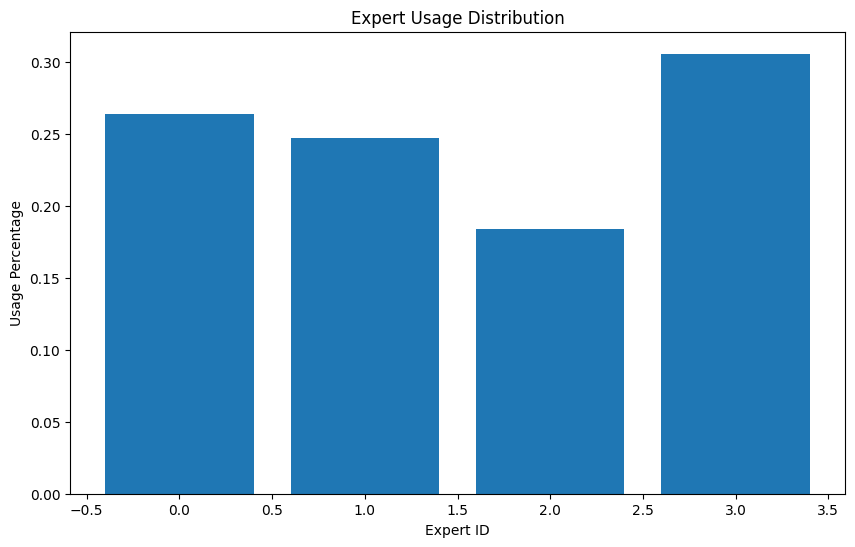

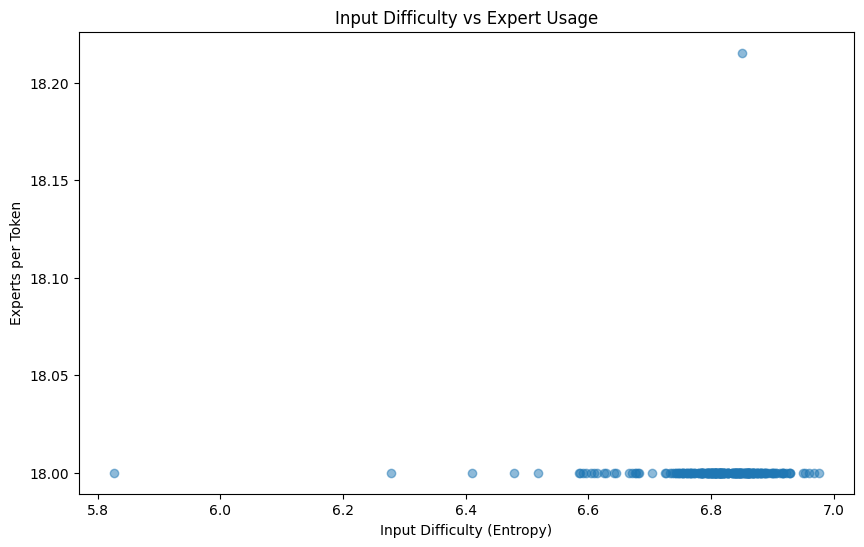

In [17]:
top_k_metrics = evaluate_expert_usage(top_k_model, test_dataloader, device)

In [27]:
top_p_results=evaluate_model(top_p_model, test_dataloader, device)

Evaluating: 100%|██████████| 238/238 [02:13<00:00,  1.79it/s]


🧪 Evaluation Results:
  - Average Loss: 9.5834
  - Perplexity: 14522.38
  - Total Inference Time: 113.53s
  - Average Time per Batch: 0.4770s
  - Average Time per Token: 0.1166 ms
  - Average Peak Memory per Batch: 7497.05 MB
  - Average Memory Used per Batch: 7497.05 MB


Evaluating Expert Usage: 100%|██████████| 238/238 [02:27<00:00,  1.61it/s]


📊 Expert Usage Metrics:
  - Average experts per token: 25.3517 ± 0.0981
  - Correlation (difficulty vs expert usage): 0.4670

Expert Distribution:
  - Expert 0: 22.91%
  - Expert 1: 26.97%
  - Expert 2: 26.98%
  - Expert 3: 23.14%


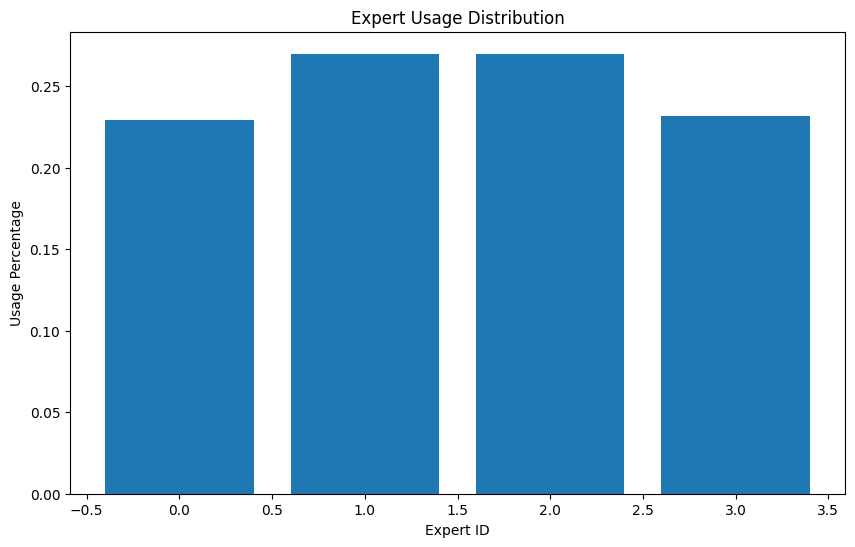

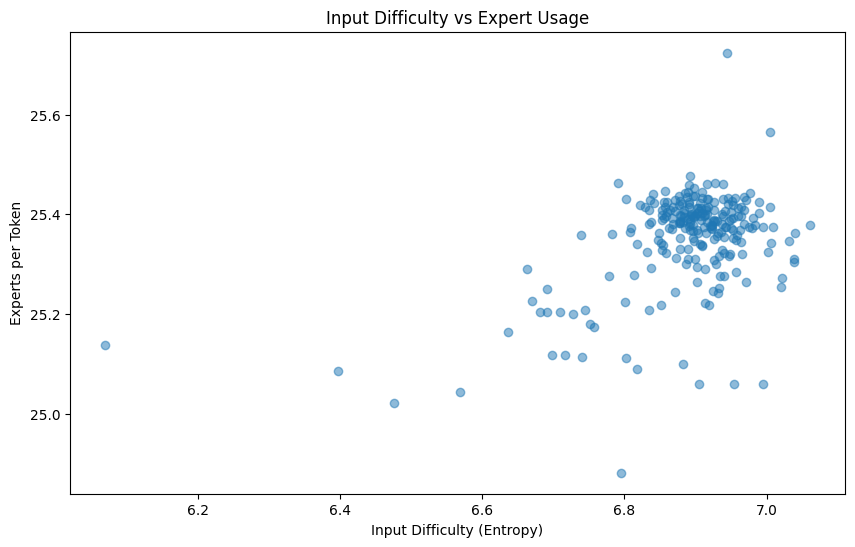

In [24]:
top_p_metrics = evaluate_expert_usage(top_p_model, test_dataloader, device)

Note that the y axis is experts per token per forward pass so across all the MoE layers